# F7 · Cribado: los once modelos con las mismas armas

**Qué pregunta responde.** Cuál de los once modelos candidatos merece pasar a la
rejilla completa, midiéndolos a todos en la misma configuración fija: **M1 × P1 × S0**,
sobre las 17 unidades y en la ventana del apartado 6.2. Y de paso, si el orden que sale
sigue a la resolución de entrada o al dominio de ajuste, que es la hipótesis del trabajo.

**Qué hay que haber corrido antes.** Una vez por entorno de modelo, diez en total:

```
conda run -n surco-mobilesam       python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-sam21           python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-microsam        python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-efficientsam    python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-edgesam         python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-efficientvitsam python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-tinysam         python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-sammed2d        python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-medsam2         python scripts/cribado.py --todos-los-checkpoints
conda run -n surco-sam1            python scripts/cribado.py --todos-los-checkpoints
```

Este notebook corre en **`surco`** y no necesita ningún entorno de modelo: solo lee los
CSV que dejaron esas diez corridas.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "scripts"))  # los scripts agregan; el notebook solo muestra

from surco import config, figuras, metricas
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

from tabla_cribado import cargar, por_familia, resumen_por_fila

# salidas/cribado_surco-*.csv  <- scripts/cribado.py, en cada entorno de modelo
tabla = cargar()
resumen = resumen_por_fila(tabla)

10 entornos, 8260 pares medidos


In [2]:
COLUMNAS = ["modelo", "checkpoint", "familia", "lado", "candidatas",
            "dice_unidad", "ic_bajo", "ic_alto", "catastroficas_unidad"]
print(resumen[COLUMNAS].to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

         modelo  checkpoint     familia  lado  candidatas  dice_unidad  ic_bajo  ic_alto  catastroficas_unidad
    microsam_lm       vit_b microscopia  1024           3       0.3389   0.2411   0.4416                0.2353
       sammed2d   sam_med2d  radiologia   256           1       0.3284   0.2732   0.3833                0.0000
    microsam_lm       vit_t microscopia  1024           3       0.2855   0.2061   0.3741                0.1176
    microsam_lm       vit_l microscopia  1024           3       0.2811   0.2023   0.3715                0.1176
        medsam2        2411  radiologia   512           3       0.2712   0.1839   0.3764                0.1176
        medsam2      latest  radiologia   512           3       0.2585   0.1855   0.3489                0.1176
    microsam_em       vit_l microscopia  1024           3       0.2499   0.1817   0.3266                0.1765
   efficientsam        vitt  eficiencia  1024           3       0.2427   0.1760   0.3230                0.2353
 

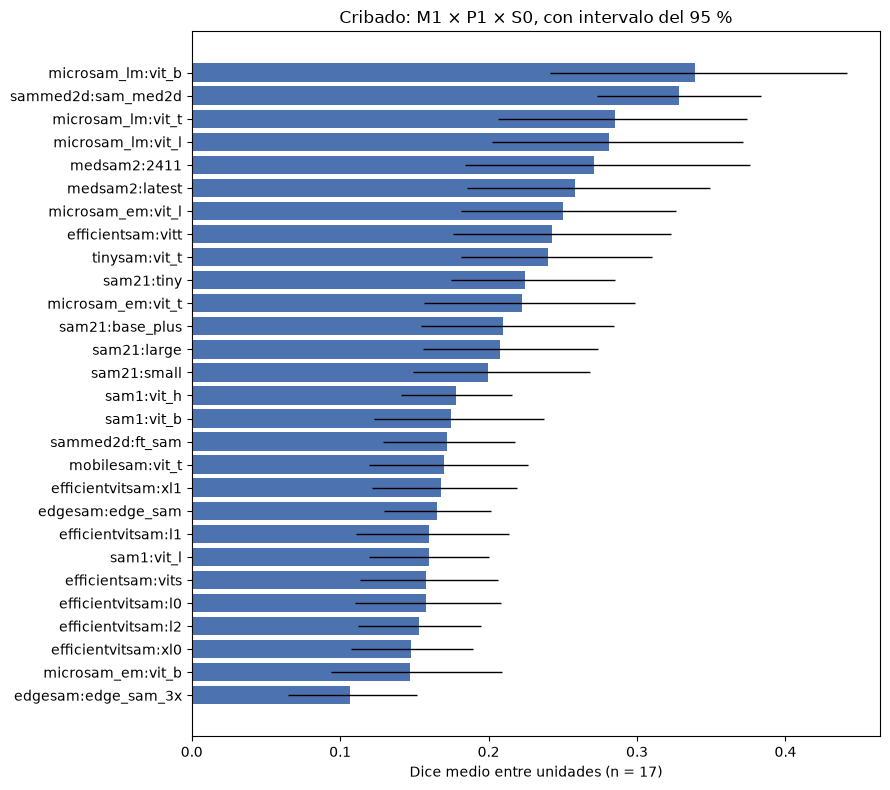

In [3]:
figura, ejes = plt.subplots(figsize=(9, 8))
orden = resumen.sort_values("dice_unidad")
etiquetas = orden["modelo"] + ":" + orden["checkpoint"].astype(str)
ejes.barh(etiquetas, orden["dice_unidad"], color="#4c72b0")
ejes.hlines(range(len(orden)), orden["ic_bajo"], orden["ic_alto"], color="black", lw=1)
ejes.set_xlabel("Dice medio entre unidades (n = 17)")
ejes.set_title("Cribado: M1 × P1 × S0, con intervalo del 95 %")
figura.tight_layout()
figuras.guardar(figura, "figura_f7_cribado.png")

In [4]:
# ¿El orden sigue a la resolución de entrada? Si lo hiciera, la comparación
# entre familias estaría midiendo píxeles y no dominio.
rho = resumen["dice_unidad"].corr(resumen["lado"], method="spearman")
print(f"Spearman entre Dice y lado de entrada: {rho:+.3f}")
print(resumen.groupby("lado")["dice_unidad"].agg(["count", "mean", "min", "max"]).to_string())
print("\nLa pareja que aísla la resolución, l contra xl de EfficientViT-SAM:")
print(resumen[resumen["modelo"] == "efficientvitsam"][["checkpoint", "lado", "dice_unidad"]].to_string(index=False))

Spearman entre Dice y lado de entrada: -0.039
      count      mean       min       max
lado                                     
256       2  0.250289  0.172140  0.328439
512       5  0.200061  0.153171  0.271162
1024     21  0.203570  0.106522  0.338877

La pareja que aísla la resolución, l contra xl de EfficientViT-SAM:
checkpoint  lado  dice_unidad
       xl1  1024     0.167898
        l1   512     0.159652
        l0   512     0.157793
        l2   512     0.153171
       xl0  1024     0.147465


In [5]:
# Coste en dos columnas (apartado 6.6): la primera incluye codificar la imagen,
# la segunda es un prompt más sobre la misma imagen ya codificada.
# salidas/coste_surco-*.csv  <- scripts/cribado.py, en cada entorno de modelo
coste = pd.concat(
    [pd.read_csv(f) for f in sorted(config.DIR_PROCESO.glob("coste_surco-*.csv"))],
    ignore_index=True,
).sort_values("coste_por_imagen_s")
print(coste.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

         modelo  checkpoint dispositivo  coste_por_imagen_s  coste_prompt_adicional_s
        medsam2        2411        cuda              0.0261                    0.0120
    microsam_em       vit_t        cuda              0.0276                    0.0083
    microsam_lm       vit_t        cuda              0.0281                    0.0099
        tinysam       vit_t        cuda              0.0285                    0.0089
        edgesam edge_sam_3x        cuda              0.0286                    0.0086
        edgesam    edge_sam        cuda              0.0302                    0.0085
efficientvitsam          l0        cuda              0.0324                    0.0085
      mobilesam       vit_t        cuda              0.0361                    0.0084
   efficientsam        vitt        cuda              0.0437                    0.0437
efficientvitsam          l1        cuda              0.0451                    0.0152
efficientvitsam         xl0        cuda              0

In [6]:
print("Por familia, un representante por modelo (apartado 6.3):")
print(por_familia(resumen).to_string(float_format=lambda v: f"{v:7.4f}"))

Por familia, un representante por modelo (apartado 6.3):
             modelos  dice_medio   mejor    peor
familia                                         
radiologia         2      0.2998  0.3284  0.2712
microscopia        2      0.2944  0.3389  0.2499
linaje             2      0.2010  0.2243  0.1778
eficiencia         5      0.1971  0.2427  0.1652
